| Column | Description |
|---|---|
| `country` | Name of the country |
| `child_mort` | Deaths of children under 5 per 1000 live births |
| `exports` | Exports of goods/services per capita (% of GDP per capita) |
| `health` | Total health spending per capita (% of GDP per capita) |
| `imports` | Imports of goods/services per capita (% of GDP per capita) |
| `income` | Net income per person |
| `inflation` | Annual growth rate of Total GDP |
| `life_expec` | Average life expectancy at birth |
| `total_fer` | Avg children born per woman |
| `gdpp` | GDP per capita |

**Strategy:**
1. Explore & understand the data using column meanings
2. Cluster countries (unsupervised) — K-Means, K-Medoids, DBSCAN, Hierarchical
3. Use cluster labels as targets → apply all supervised classifiers
4. Compare all models and find feature importances

## Step 0: Install and Import

In [69]:
!pip install xgboost lightgbm scikit-learn-extra -qq

In [30]:

%pip install "numpy<2.0"
%pip install kmedoids

%pip install --upgrade scikit-learn-extra -q --no-deps


In [70]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn_extra.cluster import KMedoids

# Pre, dim red
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    calinski_harabasz_score,
    classification_report,
    confusion_matrix,
    davies_bouldin_score,
    silhouette_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('All necessary libraries imported!')

All necessary libraries imported!


## Step 1: Load and Explore Data

In [32]:
df = pd.read_csv('/content/Country-data.csv')
print(f'Shape: {df.shape}  →  {df.shape[0]} countries, {df.shape[1]} columns')
df.head(10)

Shape: (167, 10)  →  167 countries, 10 columns


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [34]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [35]:
df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


### 1A. Feature Distributions

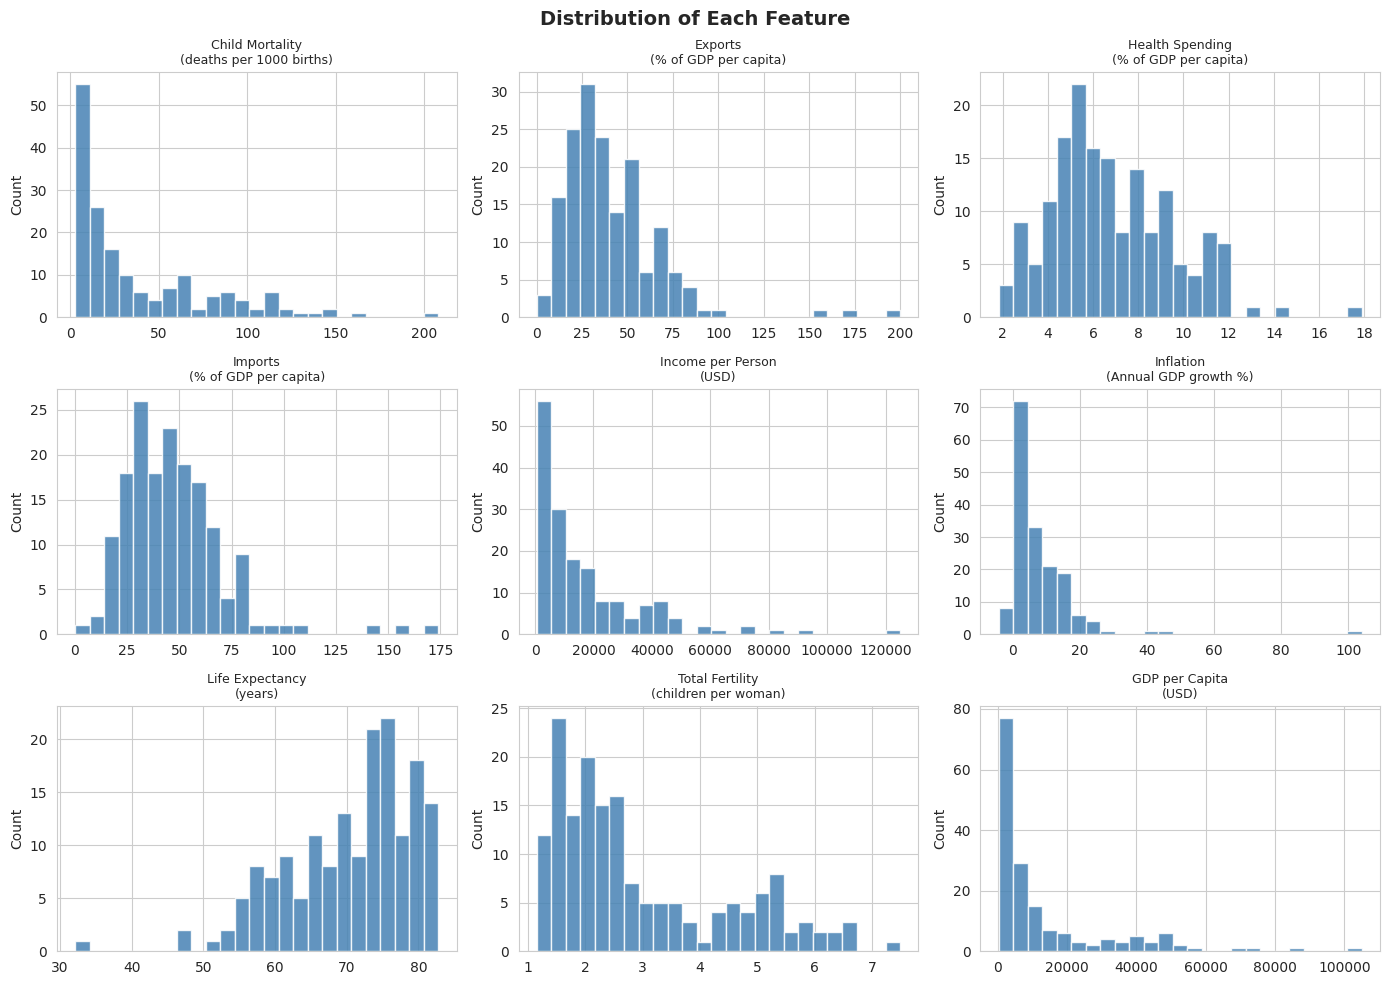

In [36]:
feature_labels = {
    'child_mort':  'Child Mortality\n(deaths per 1000 births)',
    'exports':     'Exports\n(% of GDP per capita)',
    'health':      'Health Spending\n(% of GDP per capita)',
    'imports':     'Imports\n(% of GDP per capita)',
    'income':      'Income per Person\n(USD)',
    'inflation':   'Inflation\n(Annual GDP growth %)',
    'life_expec':  'Life Expectancy\n(years)',
    'total_fer':   'Total Fertility\n(children per woman)',
    'gdpp':        'GDP per Capita\n(USD)'
}

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(feature_labels.items()):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(label, fontsize=9)
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Each Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1B. Correlation Heatmap

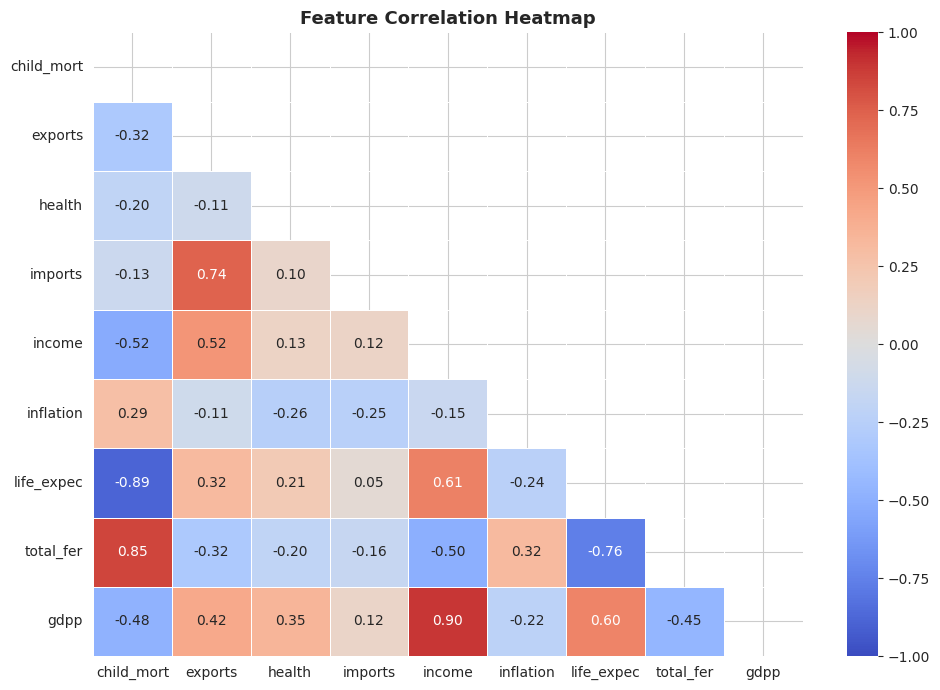

Key correlations to note:
  child_mort  vs life_expec  : -0.887  (strong negative — as expected)
  child_mort  vs total_fer   : 0.848  (high fertility linked to high child mortality)
  income      vs gdpp        : 0.896  (very high — almost the same thing)
  life_expec  vs gdpp        : 0.6  (richer countries live longer)


In [37]:
plt.figure(figsize=(10, 7))
corr = df.drop('country', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Key correlations to note:')
print('  child_mort  vs life_expec  :', round(corr.loc['child_mort','life_expec'], 3), ' (strong negative — as expected)')
print('  child_mort  vs total_fer   :', round(corr.loc['child_mort','total_fer'],  3), ' (high fertility linked to high child mortality)')
print('  income      vs gdpp        :', round(corr.loc['income','gdpp'],           3), ' (very high — almost the same thing)')
print('  life_expec  vs gdpp        :', round(corr.loc['life_expec','gdpp'],       3), ' (richer countries live longer)')

### 1C. Key Relationships (Scatter Plots)

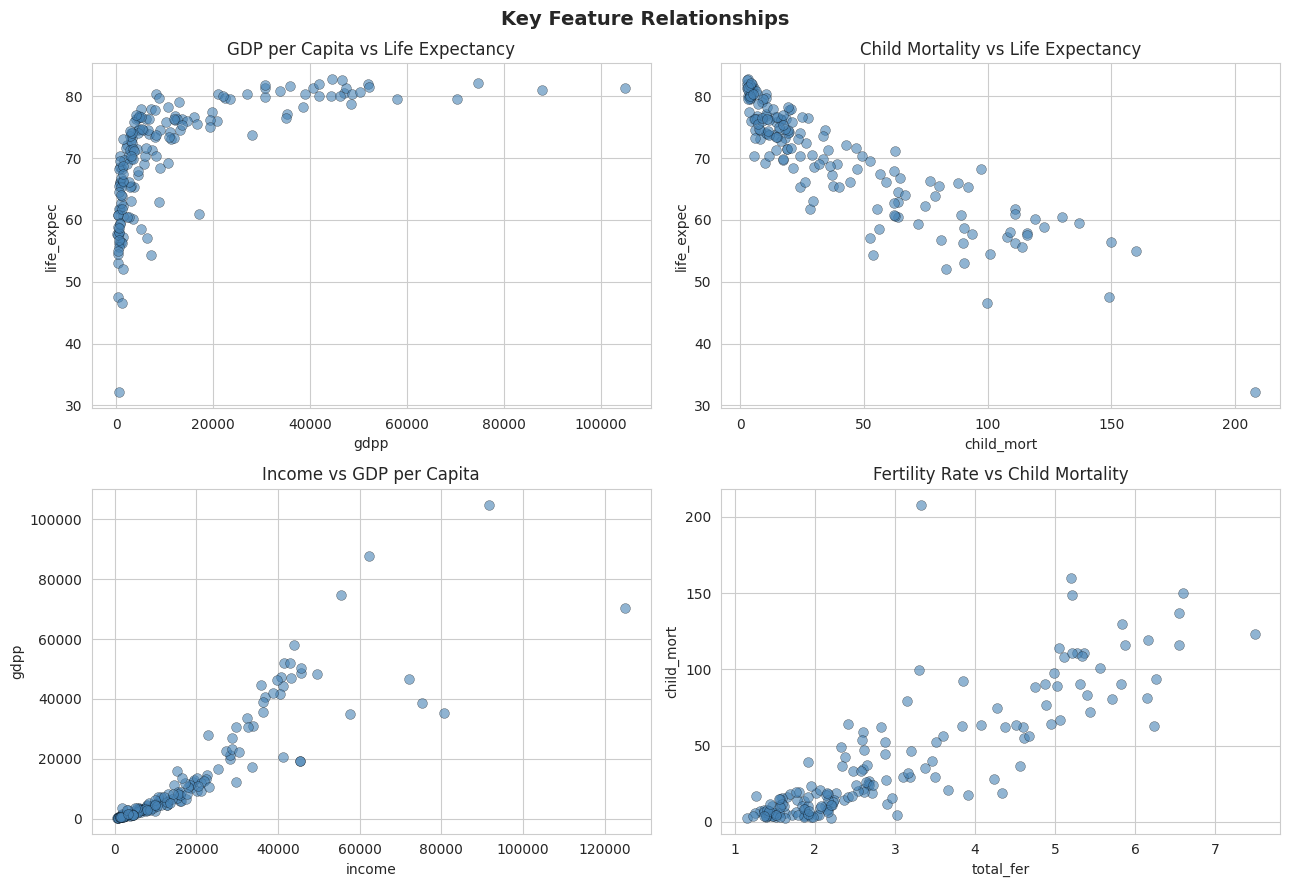

In [38]:
# Plot the most meaningful relationships between features
pairs = [
    ('gdpp',      'life_expec',  'GDP per Capita vs Life Expectancy'),
    ('child_mort','life_expec',  'Child Mortality vs Life Expectancy'),
    ('income',    'gdpp',        'Income vs GDP per Capita'),
    ('total_fer', 'child_mort',  'Fertility Rate vs Child Mortality'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (x, y, title) in enumerate(pairs):
    axes[i].scatter(df[x], df[y], alpha=0.6, color='steelblue', edgecolors='k', linewidths=0.3, s=50)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)
    axes[i].set_title(title)

plt.suptitle('Key Feature Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1D. Top/Bottom Countries by Key Indicators

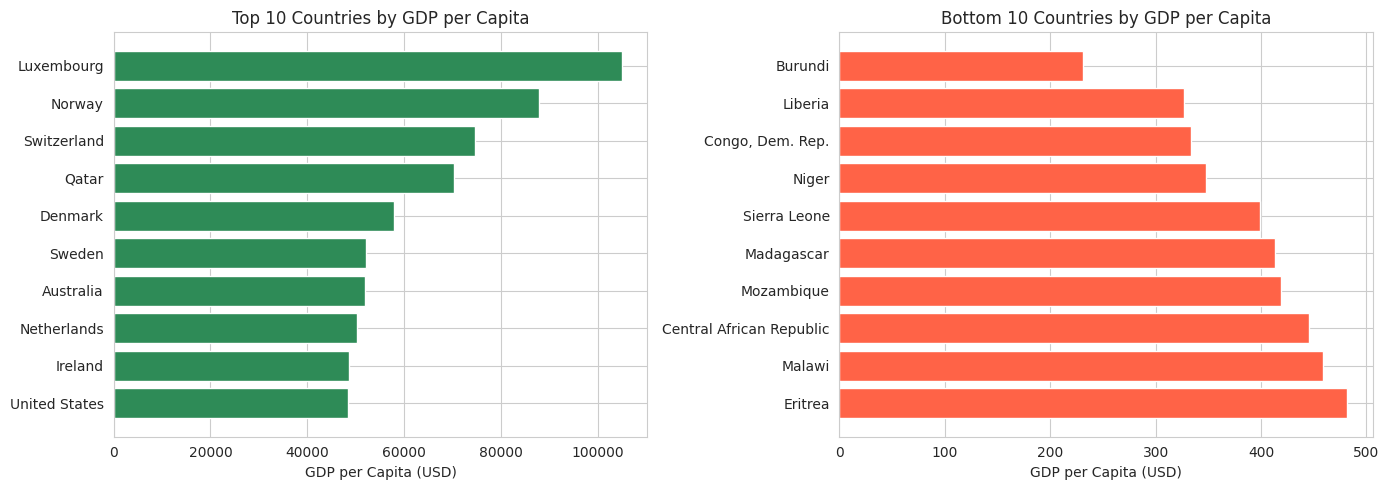

In [39]:
# Top 10 and bottom 10 by GDP per capita
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top10 = df.nlargest(10, 'gdpp')[['country','gdpp']]
bot10 = df.nsmallest(10, 'gdpp')[['country','gdpp']]

axes[0].barh(top10['country'], top10['gdpp'], color='seagreen')
axes[0].set_title('Top 10 Countries by GDP per Capita')
axes[0].set_xlabel('GDP per Capita (USD)')
axes[0].invert_yaxis()

axes[1].barh(bot10['country'], bot10['gdpp'], color='tomato')
axes[1].set_title('Bottom 10 Countries by GDP per Capita')
axes[1].set_xlabel('GDP per Capita (USD)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

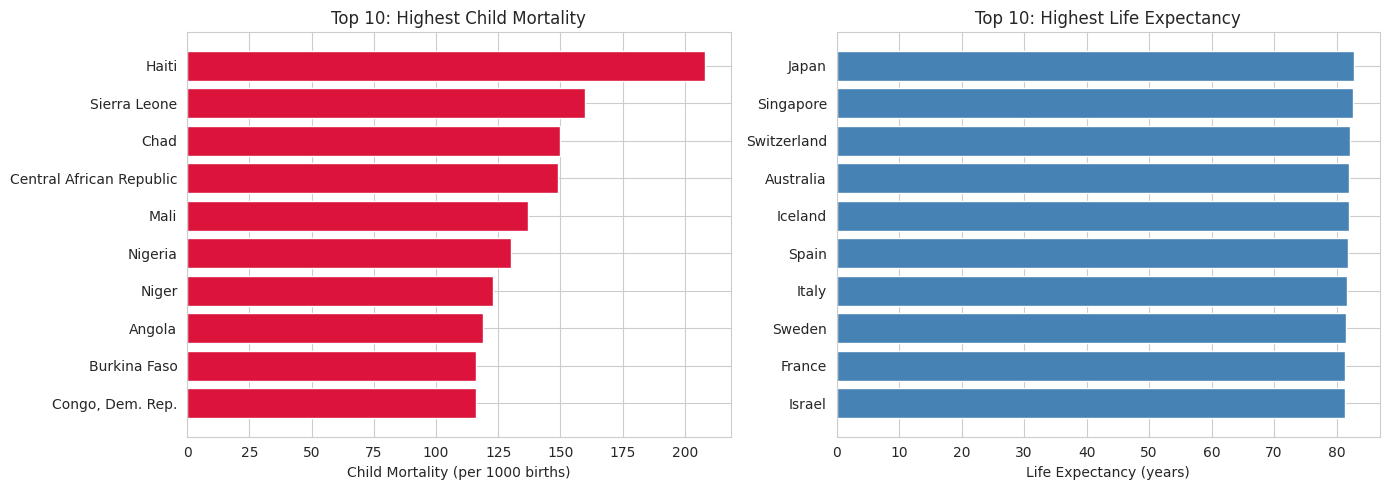

In [40]:
# Top 10 by child mortality (most at-risk countries)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_mort = df.nlargest(10, 'child_mort')[['country','child_mort']]
top_life = df.nlargest(10, 'life_expec')[['country','life_expec']]

axes[0].barh(top_mort['country'], top_mort['child_mort'], color='crimson')
axes[0].set_title('Top 10: Highest Child Mortality')
axes[0].set_xlabel('Child Mortality (per 1000 births)')
axes[0].invert_yaxis()

axes[1].barh(top_life['country'], top_life['life_expec'], color='steelblue')
axes[1].set_title('Top 10: Highest Life Expectancy')
axes[1].set_xlabel('Life Expectancy (years)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Step 2: Preprocessing

In [41]:
country_names = df['country']
X = df.drop('country', axis=1)
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape: {X_scaled.shape}')
print(f'Features: {feature_names}')

Feature matrix shape: (167, 9)
Features: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [42]:
# PCA to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'Variance captured by 2 components: {pca.explained_variance_ratio_.sum():.2%}')

# PCA loading scores
loadings = pd.DataFrame(pca.components_.T, index=feature_names, columns=['PC1','PC2']).round(3)
print('\nPCA Loadings (feature contribution to each component):')
print(loadings)

Variance captured by 2 components: 63.13%

PCA Loadings (feature contribution to each component):
              PC1    PC2
child_mort -0.420  0.193
exports     0.284  0.613
health      0.151 -0.243
imports     0.161  0.672
income      0.398  0.023
inflation  -0.193 -0.008
life_expec  0.426 -0.223
total_fer  -0.404  0.155
gdpp        0.393 -0.046


---
PART A: UNSUPERVISED LEARNING
> Goal: Group countries into natural clusters based on their socioeconomic profiles

## 3A. K-Means Clustering
> Most common clustering method — assigns each point to nearest centroid

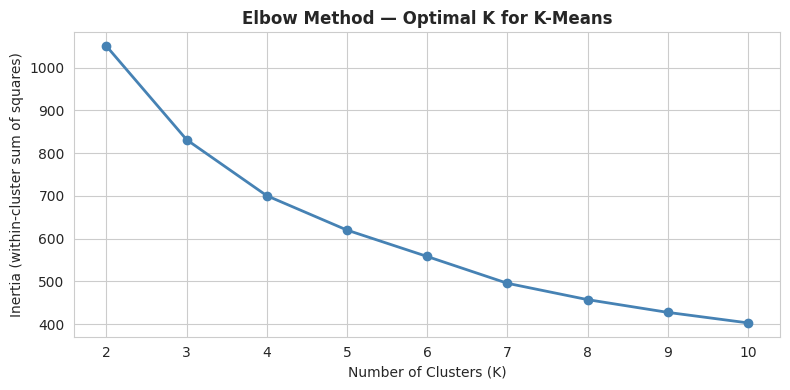

In [43]:

inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal K for K-Means', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

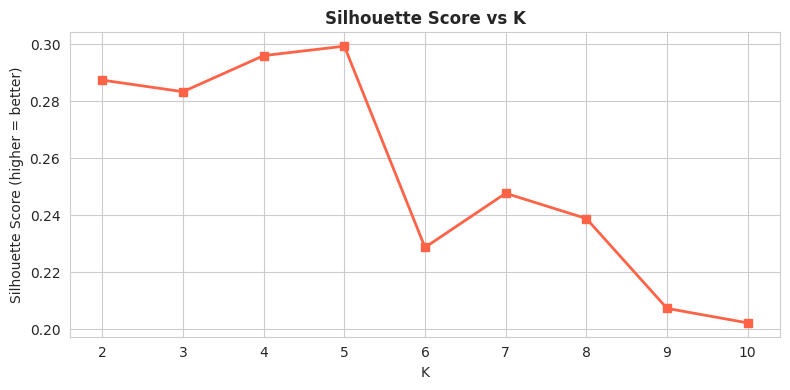

Best K (highest silhouette): 5  →  Score: 0.2993


In [44]:
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, marker='s', color='tomato', linewidth=2)
plt.title('Silhouette Score vs K', fontweight='bold')
plt.xlabel('K')
plt.ylabel('Silhouette Score (higher = better)')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f'Best K (highest silhouette): {best_k}  →  Score: {max(sil_scores):.4f}')

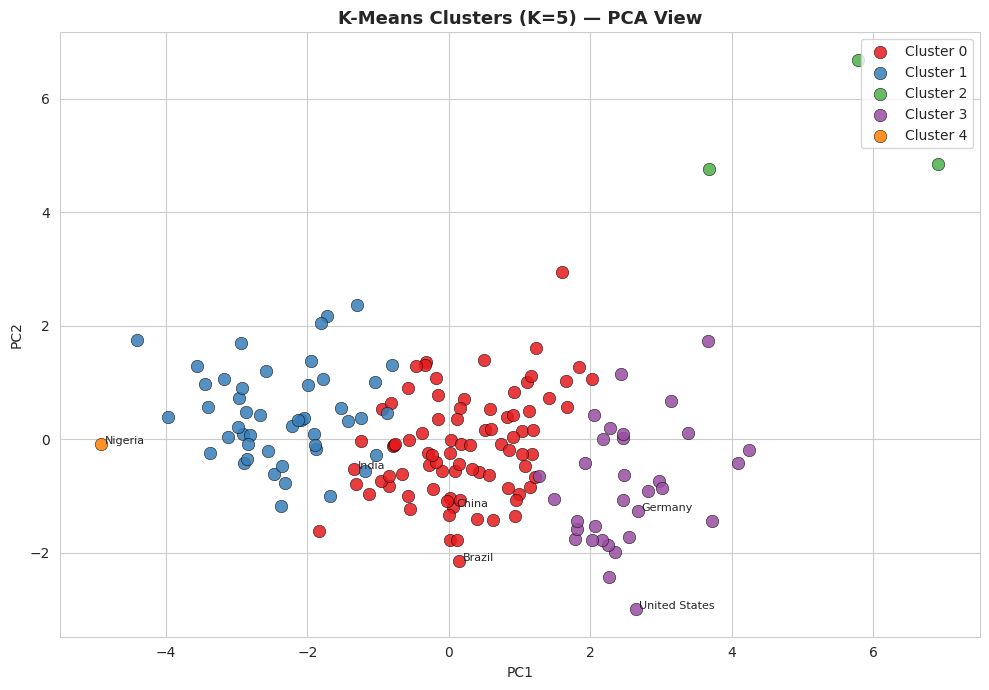

K-Means Silhouette Score: 0.2993


In [45]:
# Train final K-Means with best K
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Visualize in 2D PCA space
plt.figure(figsize=(10, 7))
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']
for c in range(best_k):
    mask = kmeans_labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}',
                s=80, edgecolors='k', linewidths=0.4, alpha=0.85, color=colors[c])

# Label a few notable countries
notable = ['United States', 'India', 'China', 'Nigeria', 'Germany', 'Brazil']
for i, name in enumerate(country_names):
    if name in notable:
        plt.annotate(name, (X_pca[i, 0]+0.05, X_pca[i, 1]), fontsize=8)

plt.legend()
plt.title(f'K-Means Clusters (K={best_k}) — PCA View', fontsize=13, fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

print(f'K-Means Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}')

Cluster Profiles (mean values — unscaled, interpretable):
         child_mort  exports  health  imports    income  inflation  life_expec  total_fer      gdpp
cluster                                                                                            
0             21.61    40.98    6.17    47.52  12801.07       7.62       73.00       2.28   6581.81
1             90.79    29.66    6.46    43.68   3870.70       9.95       59.21       4.97   1900.26
2              4.13   176.00    6.79   156.67  64033.33       2.47       81.43       1.38  57566.67
3              5.18    46.12    9.09    40.58  44021.88       2.51       80.08       1.79  42118.75
4            130.00    25.30    5.07    17.40   5150.00     104.00       60.50       5.84   2330.00


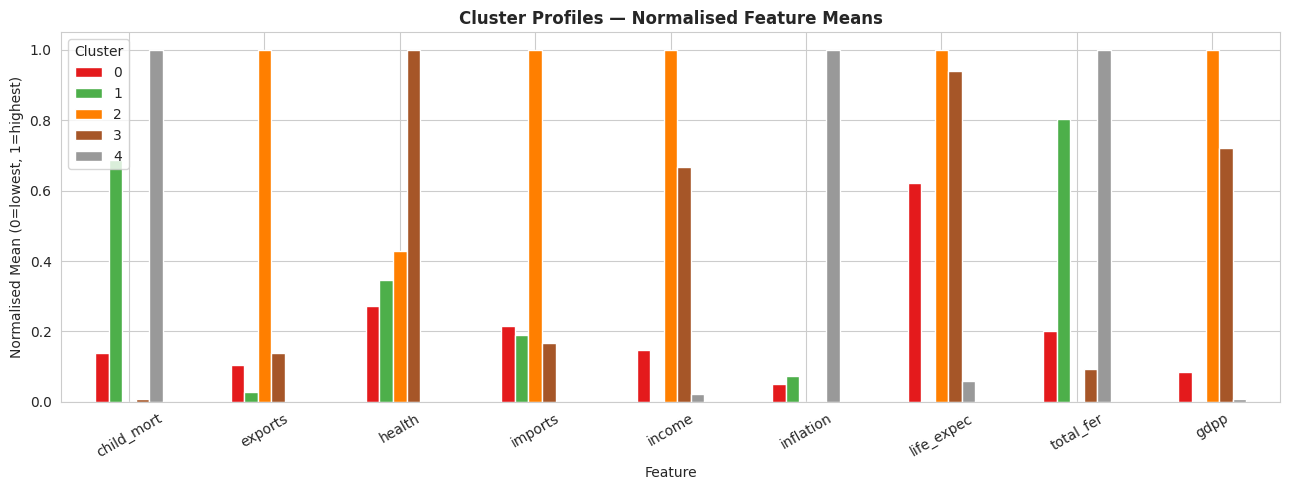

In [46]:
# Cluster profiles — what makes each cluster unique?
# Using original (unscaled) values for interpretability
df_clusters = X.copy()
df_clusters['cluster'] = kmeans_labels

profile = df_clusters.groupby('cluster').mean().round(2)
print('Cluster Profiles (mean values — unscaled, interpretable):')
print(profile.to_string())

# Visual: radar-style bar comparison
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())  # 0-1 scale for comparison
profile_norm.T.plot(kind='bar', figsize=(13, 5), colormap='Set1', edgecolor='white')
plt.title('Cluster Profiles — Normalised Feature Means', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Normalised Mean (0=lowest, 1=highest)')
plt.xticks(rotation=30)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## 3B. K-Medoids Clustering
> Uses actual data points as centers (medoids), more robust to outliers than K-Means

Cluster 0 representative country (medoid): Iran
Cluster 1 representative country (medoid): Finland
Cluster 2 representative country (medoid): Belize
Cluster 3 representative country (medoid): Tanzania
Cluster 4 representative country (medoid): Albania


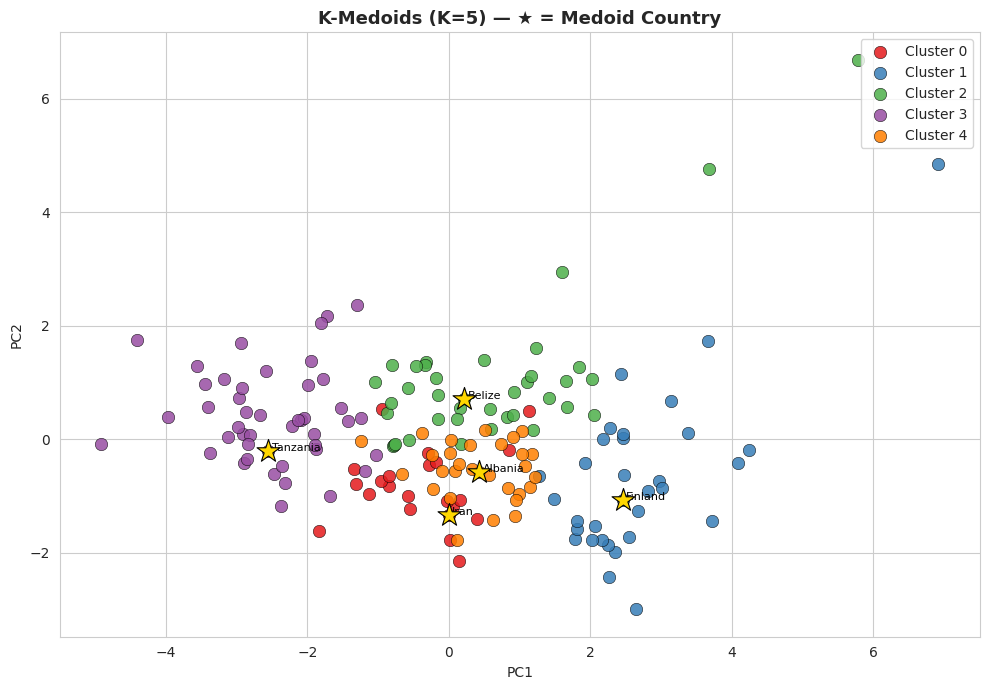

K-Medoids Silhouette Score: 0.1518


In [47]:
kmed = KMedoids(n_clusters=best_k, random_state=42)
kmed_labels = kmed.fit_predict(X_scaled)

# The medoid = most representative country in each cluster
medoid_countries = [country_names.iloc[i] for i in kmed.medoid_indices_]
for c, country in enumerate(medoid_countries):
    print(f'Cluster {c} representative country (medoid): {country}')

plt.figure(figsize=(10, 7))
for c in range(best_k):
    mask = kmed_labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}',
                s=80, edgecolors='k', linewidths=0.4, alpha=0.85, color=colors[c])

# Mark medoids
for idx in kmed.medoid_indices_:
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], marker='*', s=300, color='gold',
                edgecolors='k', linewidths=0.8, zorder=5)
    plt.annotate(country_names.iloc[idx], (X_pca[idx,0]+0.05, X_pca[idx,1]), fontsize=8, color='black')

plt.legend()
plt.title(f'K-Medoids (K={best_k}) — ★ = Medoid Country', fontsize=13, fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

print(f'K-Medoids Silhouette Score: {silhouette_score(X_scaled, kmed_labels):.4f}')

## 3C. DBSCAN Clustering
> Density-based — finds clusters of any shape, marks outlier countries as noise (-1)

DBSCAN found: 1 clusters, 30 noise/outlier countries
Outlier countries: ['Angola', 'Brunei', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Gabon', 'Haiti', 'Iraq', 'Ireland', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Luxembourg', 'Malta', 'Micronesia, Fed. Sts.', 'Mongolia', 'Nigeria', 'Norway', 'Qatar', 'Rwanda', 'Seychelles', 'Sierra Leone', 'Singapore', 'South Africa', 'Timor-Leste', 'Turkmenistan', 'United States', 'Venezuela']


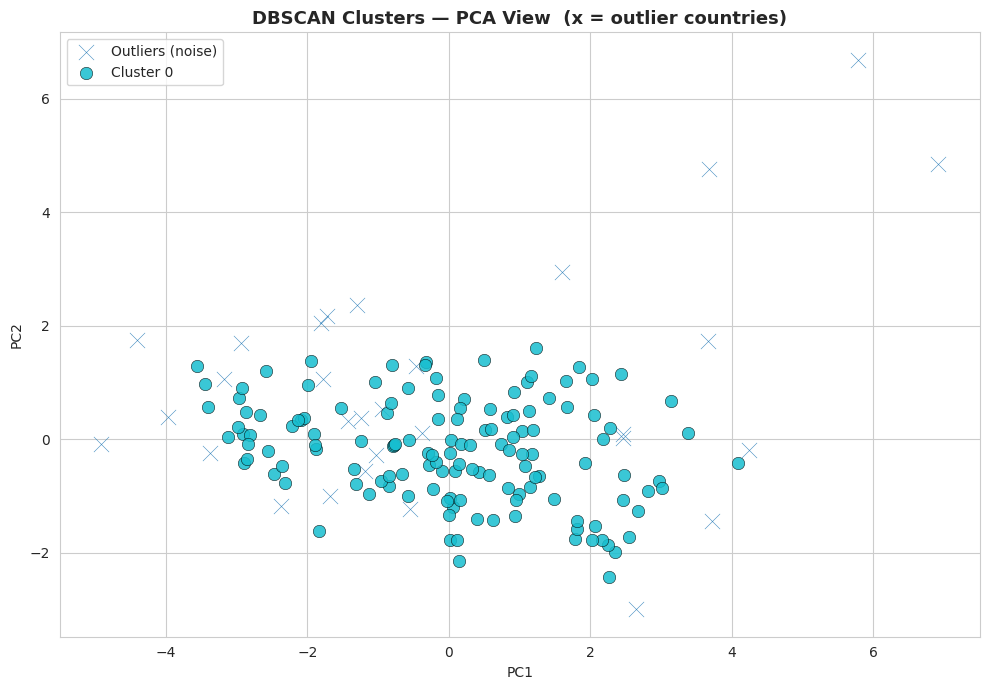

In [48]:
# eps = neighbourhood radius, min_samples = min points to form a cluster
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f'DBSCAN found: {n_clusters_db} clusters, {n_noise} noise/outlier countries')

# Print the outlier countries
if n_noise > 0:
    outliers = country_names[dbscan_labels == -1].tolist()
    print(f'Outlier countries: {outliers}')

plt.figure(figsize=(10, 7))
unique_labels = sorted(set(dbscan_labels))
cmap = plt.cm.get_cmap('tab10', len(unique_labels))
for i, label in enumerate(unique_labels):
    mask = dbscan_labels == label
    cluster_name = f'Cluster {label}' if label != -1 else 'Outliers (noise)'
    marker = 'x' if label == -1 else 'o'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cluster_name,
                s=80 if label != -1 else 120, marker=marker,
                edgecolors='k' if label != -1 else None,
                linewidths=0.4, alpha=0.85, color=cmap(i))

plt.legend()
plt.title('DBSCAN Clusters — PCA View  (x = outlier countries)', fontsize=13, fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

if n_clusters_db > 1:
    mask = dbscan_labels != -1
    print(f'DBSCAN Silhouette Score (excluding noise): {silhouette_score(X_scaled[mask], dbscan_labels[mask]):.4f}')

## 3D. Hierarchical Clustering
> Builds a tree of merges — dendrogram shows which countries are most similar

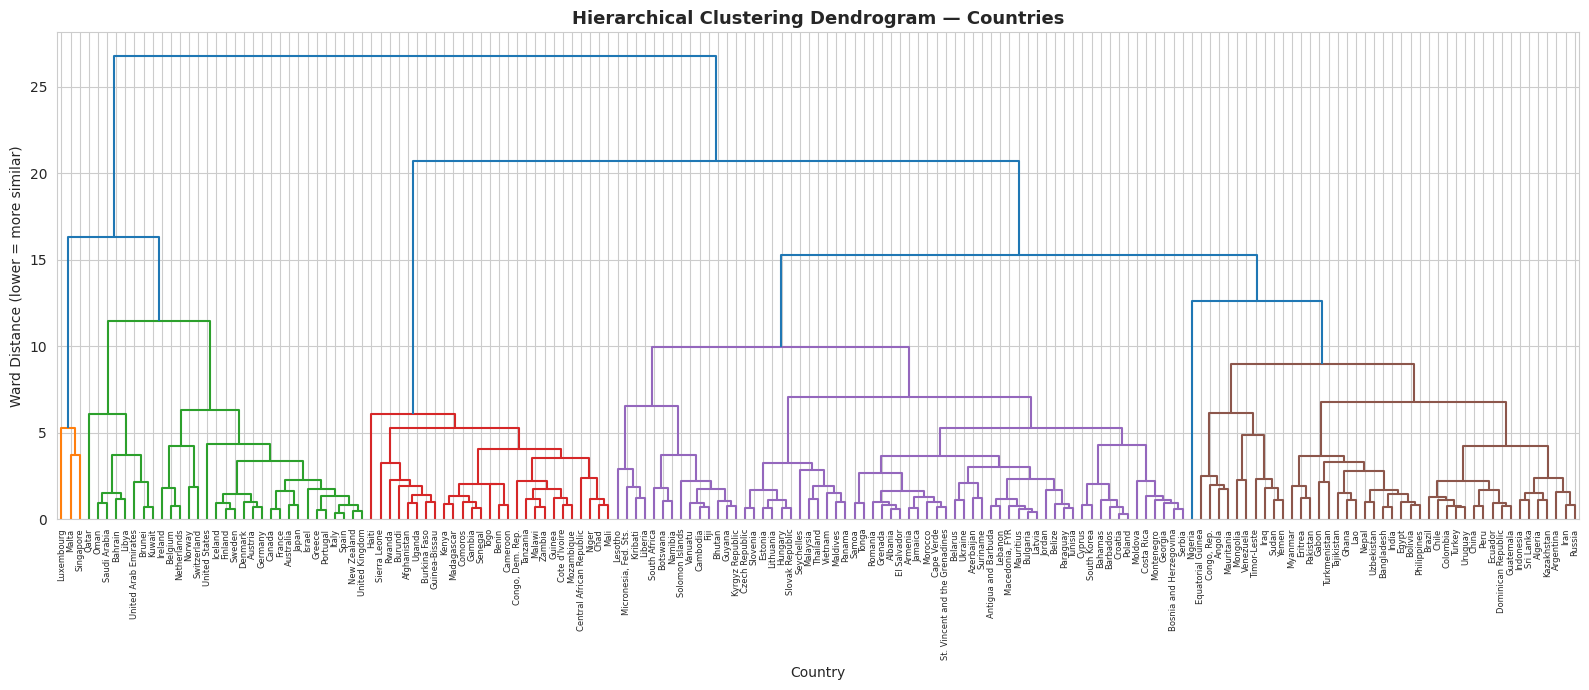

In [49]:
# Ward linkage minimises within-cluster variance at each merge step
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(16, 7))
dendrogram(linked, labels=country_names.values, leaf_rotation=90,
           leaf_font_size=6, color_threshold=12)
plt.title('Hierarchical Clustering Dendrogram — Countries', fontsize=13, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Ward Distance (lower = more similar)')
plt.tight_layout()
plt.show()

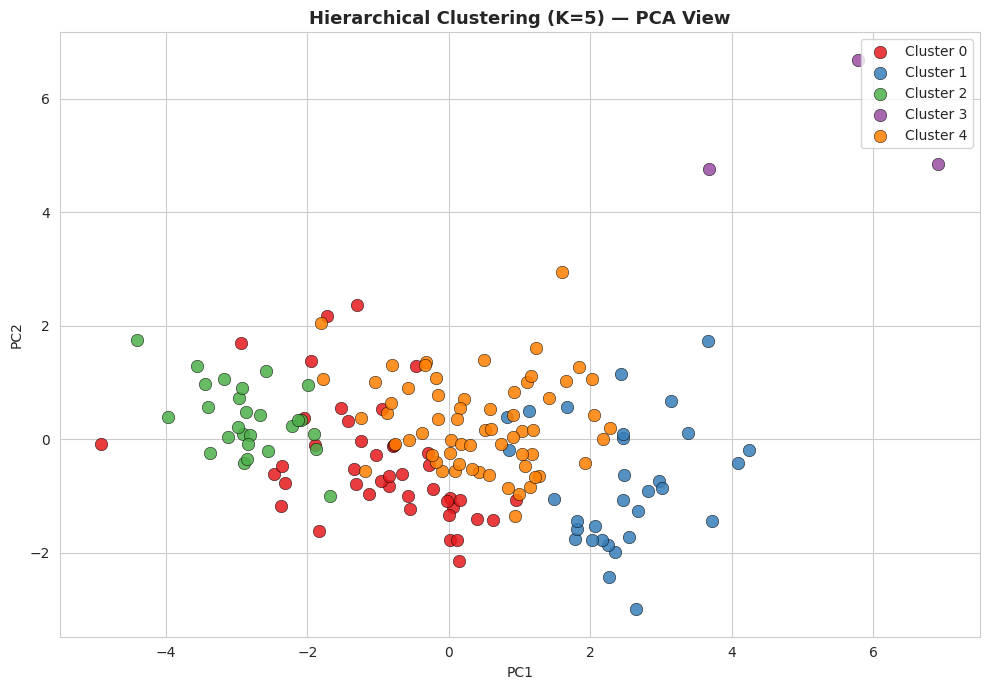

Hierarchical Silhouette Score: 0.2193


In [50]:
# Cut the dendrogram at best_k clusters
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

plt.figure(figsize=(10, 7))
for c in range(best_k):
    mask = agg_labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}',
                s=80, edgecolors='k', linewidths=0.4, alpha=0.85, color=colors[c])

plt.legend()
plt.title(f'Hierarchical Clustering (K={best_k}) — PCA View', fontsize=13, fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

print(f'Hierarchical Silhouette Score: {silhouette_score(X_scaled, agg_labels):.4f}')

## 3E. Clustering Evaluation Summary
> Three standard metrics to compare all clustering methods objectively

In [51]:
# Silhouette:          higher is better (−1 to 1)
# Davies-Bouldin:      lower is better  (0 = perfect)
# Calinski-Harabasz:   higher is better (dense, well-separated clusters)

results = {}
for name, labels in [('K-Means', kmeans_labels), ('K-Medoids', kmed_labels), ('Hierarchical', agg_labels)]:
    results[name] = {
        'Silhouette ↑':         round(silhouette_score(X_scaled, labels), 4),
        'Davies-Bouldin ↓':     round(davies_bouldin_score(X_scaled, labels), 4),
        'Calinski-Harabasz ↑':  round(calinski_harabasz_score(X_scaled, labels), 2)
    }

if n_clusters_db > 1:
    mask = dbscan_labels != -1
    results['DBSCAN'] = {
        'Silhouette ↑':         round(silhouette_score(X_scaled[mask], dbscan_labels[mask]), 4),
        'Davies-Bouldin ↓':     round(davies_bouldin_score(X_scaled[mask], dbscan_labels[mask]), 4),
        'Calinski-Harabasz ↑':  round(calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask]), 2)
    }

eval_df = pd.DataFrame(results).T
print('Clustering Evaluation (↑ = higher better, ↓ = lower better):')
print(eval_df.to_string())

Clustering Evaluation (↑ = higher better, ↓ = lower better):
              Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
K-Means             0.2993            0.8718                57.65
K-Medoids           0.1518            1.4851                41.95
Hierarchical        0.2193            1.3008                49.15


## 3F. Countries in Each Cluster
> Interpret what each cluster means using real country context

In [52]:
# Assign K-Means labels back to original df
df_full = df.copy()
df_full['cluster'] = kmeans_labels

for c in sorted(df_full['cluster'].unique()):
    subset = df_full[df_full['cluster'] == c]
    countries = subset['country'].tolist()
    avg_gdp = subset['gdpp'].mean()
    avg_child_mort = subset['child_mort'].mean()
    avg_life = subset['life_expec'].mean()
    print(f"\nCluster {c} — {len(countries)} countries")
    print(f"  Avg GDP/capita: ${avg_gdp:,.0f} | Child Mort: {avg_child_mort:.1f} | Life Exp: {avg_life:.1f} yrs")
    print(f"  Countries: {', '.join(countries)}")


Cluster 0 — 84 countries
  Avg GDP/capita: $6,582 | Child Mort: 21.6 | Life Exp: 73.0 yrs
  Countries: Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahrain, Bangladesh, Barbados, Belarus, Belize, Bhutan, Bolivia, Bosnia and Herzegovina, Brazil, Bulgaria, Cambodia, Cape Verde, Chile, China, Colombia, Costa Rica, Croatia, Dominican Republic, Ecuador, Egypt, El Salvador, Estonia, Fiji, Georgia, Grenada, Guatemala, Guyana, Hungary, India, Indonesia, Iran, Jamaica, Jordan, Kazakhstan, Kyrgyz Republic, Latvia, Lebanon, Libya, Lithuania, Macedonia, FYR, Malaysia, Maldives, Mauritius, Micronesia, Fed. Sts., Moldova, Mongolia, Montenegro, Morocco, Myanmar, Nepal, Oman, Panama, Paraguay, Peru, Philippines, Poland, Romania, Russia, Samoa, Saudi Arabia, Serbia, Seychelles, Slovak Republic, Sri Lanka, St. Vincent and the Grenadines, Suriname, Tajikistan, Thailand, Tonga, Tunisia, Turkey, Turkmenistan, Ukraine, Uruguay, Uzbekistan, Vanuatu, Venezuela, Vietnam

Cluster 1 — 

---
PART B: SUPERVISED LEARNING

> **Approach:** We use K-Means cluster labels as our target variable `y`.
> This is valid because clusters represent distinct socioeconomic country groups.  
> Training classifiers on these labels shows which algorithm can best learn the cluster boundaries.

In [53]:
# Target = KMeans cluster label
y = kmeans_labels

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')
print(f'Classes (clusters): {np.unique(y)}')
print(f'Class distribution in train: {dict(zip(*np.unique(y_train, return_counts=True)))}')

Train size: 133  |  Test size: 34
Classes (clusters): [0 1 2 3 4]
Class distribution in train: {0: 65, 1: 40, 2: 1, 3: 26, 4: 1}


## 4A. Logistic Regression
> Linear classifier — finds a decision boundary using log-odds. Works well when clusters are linearly separable.

In [54]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print('=== Logistic Regression ===')
print(f'Test Accuracy : {accuracy_score(y_test, lr_pred):.4f}')
print(classification_report(y_test, lr_pred))

=== Logistic Regression ===
Test Accuracy : 0.9706
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.88      1.00      0.93         7
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         6

    accuracy                           0.97        34
   macro avg       0.97      0.99      0.98        34
weighted avg       0.97      0.97      0.97        34



## 4B. Naive Bayes
> Probabilistic classifier — assumes features are independent (naive). Fast and surprisingly effective.

In [55]:
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

print('=== Gaussian Naive Bayes ===')
print(f'Test Accuracy : {accuracy_score(y_test, nb_pred):.4f}')
print(classification_report(y_test, nb_pred))

=== Gaussian Naive Bayes ===
Test Accuracy : 0.9118
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.88      1.00      0.93         7
           2       0.00      0.00      0.00         2
           3       0.75      1.00      0.86         6

    accuracy                           0.91        34
   macro avg       0.66      0.74      0.69        34
weighted avg       0.87      0.91      0.89        34



## 4C. K-Nearest Neighbors (KNN)
> Classifies by majority vote of K closest training points. No model training — purely memory-based.

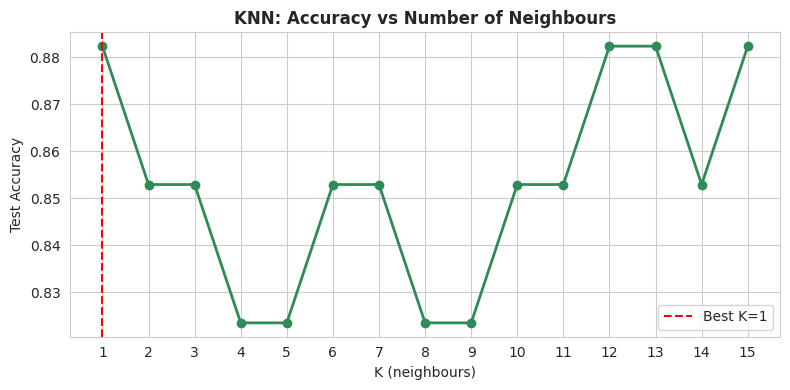

=== KNN (K=1) ===
Test Accuracy : 0.8824
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        19
           1       0.83      0.71      0.77         7
           2       1.00      0.50      0.67         2
           3       1.00      1.00      1.00         6

    accuracy                           0.88        34
   macro avg       0.92      0.79      0.83        34
weighted avg       0.89      0.88      0.88        34



In [56]:
# Try K = 1 to 15, pick the one with best test accuracy
knn_acc = []
k_vals = range(1, 16)
for k in k_vals:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train, y_train)
    knn_acc.append(accuracy_score(y_test, knn_tmp.predict(X_test)))

best_knn_k = k_vals[np.argmax(knn_acc)]

plt.figure(figsize=(8, 4))
plt.plot(k_vals, knn_acc, marker='o', color='seagreen', linewidth=2)
plt.axvline(best_knn_k, color='red', linestyle='--', label=f'Best K={best_knn_k}')
plt.title('KNN: Accuracy vs Number of Neighbours', fontweight='bold')
plt.xlabel('K (neighbours)')
plt.ylabel('Test Accuracy')
plt.legend()
plt.xticks(k_vals)
plt.tight_layout()
plt.show()

# Final KNN with best K
knn = KNeighborsClassifier(n_neighbors=best_knn_k)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print(f'=== KNN (K={best_knn_k}) ===')
print(f'Test Accuracy : {accuracy_score(y_test, knn_pred):.4f}')
print(classification_report(y_test, knn_pred))

## 4D. Support Vector Machine (SVM)
> Finds the maximum-margin hyperplane separating clusters. RBF kernel handles non-linear boundaries.

In [57]:
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

print('=== SVM (RBF Kernel) ===')
print(f'Test Accuracy : {accuracy_score(y_test, svm_pred):.4f}')
print(classification_report(y_test, svm_pred))

=== SVM (RBF Kernel) ===
Test Accuracy : 0.9118
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.78      1.00      0.88         7
           2       0.00      0.00      0.00         2
           3       1.00      1.00      1.00         6

    accuracy                           0.91        34
   macro avg       0.68      0.74      0.71        34
weighted avg       0.87      0.91      0.89        34



## 4E. Decision Tree
> Splits data by asking yes/no questions on features. Highly interpretable — you can visualise the exact rules.

In [58]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print('=== Decision Tree (max_depth=5) ===')
print(f'Test Accuracy : {accuracy_score(y_test, dt_pred):.4f}')
print(classification_report(y_test, dt_pred))

# Top split feature = most important discriminator
print(f'\nTop split feature: {feature_names[dt.tree_.feature[0]]}  (the first question the tree asks)')

=== Decision Tree (max_depth=5) ===
Test Accuracy : 0.9706
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.86      0.92         7
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         6

    accuracy                           0.97        34
   macro avg       0.99      0.96      0.97        34
weighted avg       0.97      0.97      0.97        34


Top split feature: child_mort  (the first question the tree asks)


## 4F. Random Forest
> Ensemble of 100 decision trees — each trained on a random subset of data and features. Much more stable than a single tree.

In [59]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('=== Random Forest (100 trees) ===')
print(f'Test Accuracy : {accuracy_score(y_test, rf_pred):.4f}')
print(classification_report(y_test, rf_pred))

=== Random Forest (100 trees) ===
Test Accuracy : 0.9412
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      1.00      1.00         7
           2       0.00      0.00      0.00         2
           3       0.86      1.00      0.92         6

    accuracy                           0.94        34
   macro avg       0.70      0.75      0.72        34
weighted avg       0.89      0.94      0.91        34



## 4G. Feature Importance
> Which features are most useful for distinguishing the country groups?

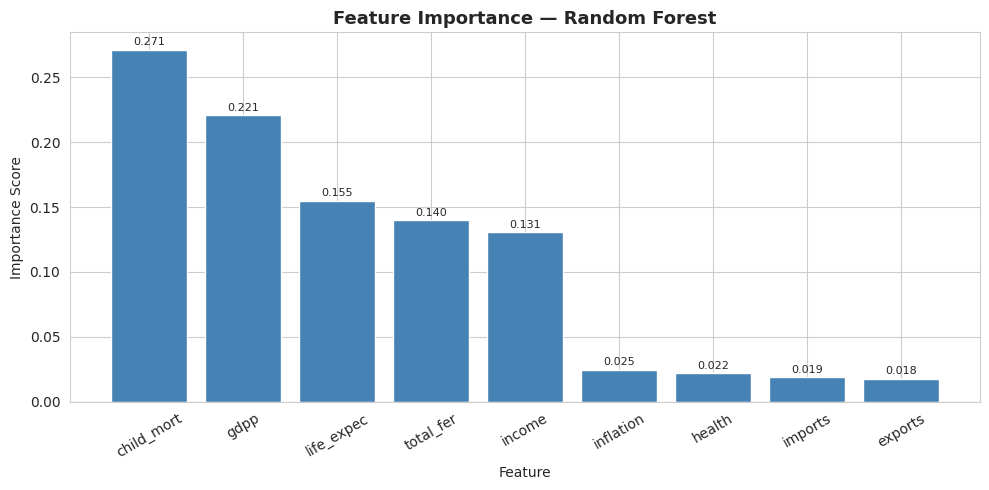


Feature Importance Ranking:
Rank  Feature         Importance   What it measures
-----------------------------------------------------------------
1     child_mort      0.2710       Child deaths per 1000 births
2     gdpp            0.2208       GDP per capita
3     life_expec      0.1548       Average life expectancy (years)
4     total_fer       0.1398       Avg children per woman
5     income          0.1305       Net income per person
6     inflation       0.0247       Annual GDP growth rate
7     health          0.0219       Health spend as % of GDP/capita
8     imports         0.0189       Imports as % of GDP/capita
9     exports         0.0176       Exports as % of GDP/capita


In [60]:
# Random Forest feature importances = average reduction in impurity per feature
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]  # sort descending

plt.figure(figsize=(10, 5))
bars = plt.bar(np.array(feature_names)[idx], importances[idx], color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=30)

# Add value labels on bars
for bar, val in zip(bars, importances[idx]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.3f}',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print('\nFeature Importance Ranking:')
print(f'{"Rank":<5} {"Feature":<15} {"Importance":<12} What it measures')
print('-'*65)
descriptions = {
    'child_mort': 'Child deaths per 1000 births',
    'exports':    'Exports as % of GDP/capita',
    'health':     'Health spend as % of GDP/capita',
    'imports':    'Imports as % of GDP/capita',
    'income':     'Net income per person',
    'inflation':  'Annual GDP growth rate',
    'life_expec': 'Average life expectancy (years)',
    'total_fer':  'Avg children per woman',
    'gdpp':       'GDP per capita'
}
for rank, i in enumerate(idx, 1):
    fn = feature_names[i]
    print(f'{rank:<5} {fn:<15} {importances[i]:<12.4f} {descriptions[fn]}')

## 4H. AdaBoost
> Boosting: trains trees sequentially, each one focusing more on the mistakes of the previous ones.

In [61]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

print('=== AdaBoost (100 estimators) ===')
print(f'Test Accuracy : {accuracy_score(y_test, ada_pred):.4f}')
print(classification_report(y_test, ada_pred))

=== AdaBoost (100 estimators) ===
Test Accuracy : 0.8824
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.86      0.86      0.86         7
           2       0.00      0.00      0.00         2
           3       0.75      1.00      0.86         6

    accuracy                           0.88        34
   macro avg       0.64      0.70      0.67        34
weighted avg       0.84      0.88      0.86        34



## 4I. Gradient Boosting
> Builds trees one at a time, each correcting the residual errors of the previous — more powerful than AdaBoost.

In [62]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

print('=== Gradient Boosting ===')
print(f'Test Accuracy : {accuracy_score(y_test, gb_pred):.4f}')
print(classification_report(y_test, gb_pred))

=== Gradient Boosting ===
Test Accuracy : 0.9118
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        19
           1       1.00      0.86      0.92         7
           2       0.00      0.00      0.00         2
           3       0.86      1.00      0.92         6

    accuracy                           0.91        34
   macro avg       0.69      0.71      0.70        34
weighted avg       0.86      0.91      0.88        34



## 4J. XGBoost
> Optimised gradient boosting with regularisation — generally the best performer on tabular data.

In [63]:
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print('=== XGBoost ===')
print(f'Test Accuracy : {accuracy_score(y_test, xgb_pred):.4f}')
print(classification_report(y_test, xgb_pred))

=== XGBoost ===
Test Accuracy : 0.9118
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.88      1.00      0.93         7
           2       0.00      0.00      0.00         2
           3       0.86      1.00      0.92         6

    accuracy                           0.91        34
   macro avg       0.67      0.74      0.70        34
weighted avg       0.86      0.91      0.88        34



## 4K. LightGBM
> Microsoft's faster gradient boosting — uses leaf-wise tree growth and histogram-based splits.

In [64]:
lgbm = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)

print('=== LightGBM ===')
print(f'Test Accuracy : {accuracy_score(y_test, lgbm_pred):.4f}')
print(classification_report(y_test, lgbm_pred))

=== LightGBM ===
Test Accuracy : 0.9412
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00         7
           2       0.00      0.00      0.00         2
           3       0.75      1.00      0.86         6

    accuracy                           0.94        34
   macro avg       0.69      0.75      0.71        34
weighted avg       0.90      0.94      0.92        34



## 4L. Stacking Classifier
> Meta-learning: trains multiple base models, then trains a final model on their predictions — combines strengths of different models.

In [65]:
# Base models: diverse approaches
base_models = [
    ('dt',  DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=best_knn_k)),
    ('nb',  GaussianNB())
]

# Meta-learner: takes base model outputs as input features
stack = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5  # base models trained on 5-fold CV predictions to avoid leakage
)
stack.fit(X_train, y_train)
stack_pred = stack.predict(X_test)

print('=== Stacking (DT + KNN + NB → LogReg) ===')
print(f'Test Accuracy : {accuracy_score(y_test, stack_pred):.4f}')
print(classification_report(y_test, stack_pred))

=== Stacking (DT + KNN + NB → LogReg) ===
Test Accuracy : 0.8529
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        19
           1       0.83      0.71      0.77         7
           2       0.00      0.00      0.00         2
           3       0.86      1.00      0.92         6

    accuracy                           0.85        34
   macro avg       0.64      0.67      0.65        34
weighted avg       0.80      0.85      0.82        34



---
## Step 5: Final Model Comparison and Evaluation

In [66]:
# All model names and their test predictions
model_names = [
    'Logistic Regression', 'Naive Bayes', 'KNN', 'SVM',
    'Decision Tree', 'Random Forest', 'AdaBoost',
    'Gradient Boosting', 'XGBoost', 'LightGBM', 'Stacking'
]
all_models   = [lr, nb, knn, svm, dt, rf, ada, gb, xgb, lgbm, stack]
all_preds    = [lr_pred, nb_pred, knn_pred, svm_pred, dt_pred, rf_pred,
                ada_pred, gb_pred, xgb_pred, lgbm_pred, stack_pred]

# Test accuracy & 5-fold cross-validation accuracy
test_accs = [accuracy_score(y_test, p) for p in all_preds]
cv_accs   = [cross_val_score(m, X_scaled, y, cv=5, scoring='accuracy').mean() for m in all_models]

comparison_df = pd.DataFrame({
    'Model':              model_names,
    'Test Accuracy':      [round(a, 4) for a in test_accs],
    'CV Accuracy (5-fold)': [round(a, 4) for a in cv_accs]
}).sort_values('CV Accuracy (5-fold)', ascending=False).reset_index(drop=True)

print('All Models Ranked by Cross-Validation Accuracy:')
print(comparison_df.to_string(index=False))

All Models Ranked by Cross-Validation Accuracy:
              Model  Test Accuracy  CV Accuracy (5-fold)
                KNN         0.8824                0.9702
           LightGBM         0.9412                0.9702
Logistic Regression         0.9706                0.9642
                SVM         0.9118                0.9642
      Random Forest         0.9412                0.9583
           Stacking         0.8529                0.9463
            XGBoost         0.9118                0.9342
  Gradient Boosting         0.9118                0.9339
        Naive Bayes         0.9118                0.9160
      Decision Tree         0.9706                0.9098
           AdaBoost         0.8824                0.8631


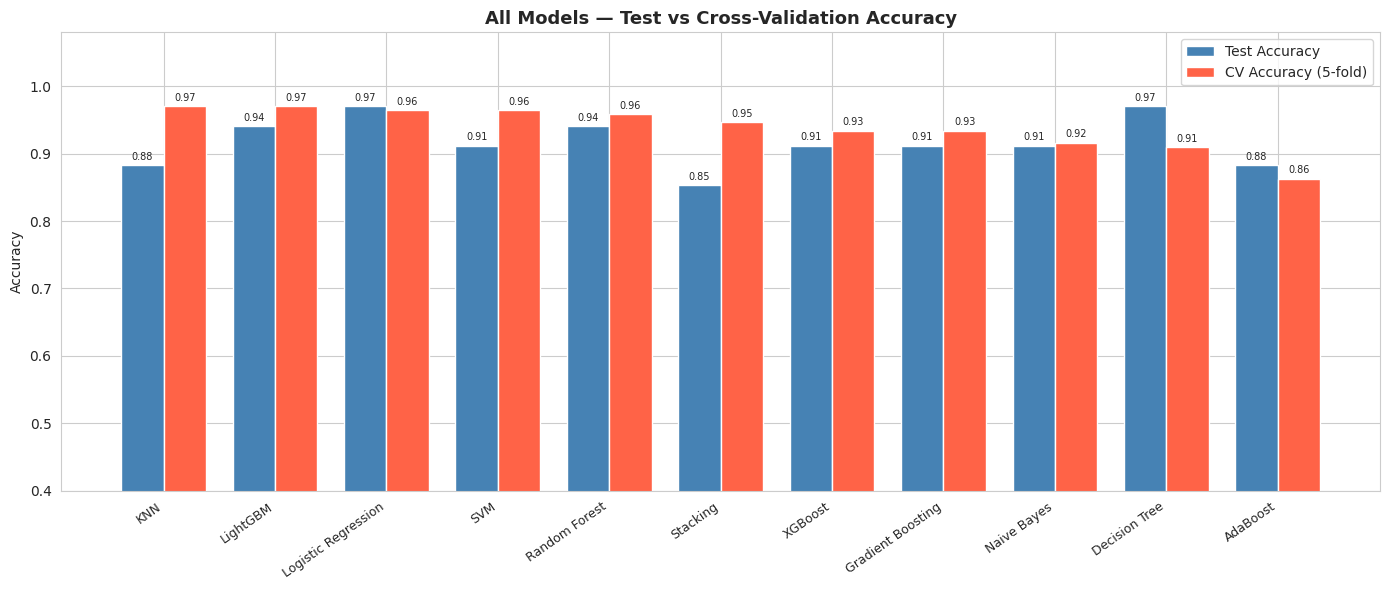

In [67]:
# Side-by-side bar chart
ordered_names  = comparison_df['Model'].tolist()
ordered_test   = comparison_df['Test Accuracy'].tolist()
ordered_cv     = comparison_df['CV Accuracy (5-fold)'].tolist()

x = np.arange(len(ordered_names))
w = 0.38

plt.figure(figsize=(14, 6))
bars1 = plt.bar(x - w/2, ordered_test, w, label='Test Accuracy',    color='steelblue', edgecolor='white')
bars2 = plt.bar(x + w/2, ordered_cv,   w, label='CV Accuracy (5-fold)', color='tomato',  edgecolor='white')

plt.xticks(x, ordered_names, rotation=35, ha='right', fontsize=9)
plt.ylim(0.4, 1.08)
plt.ylabel('Accuracy')
plt.title('All Models — Test vs Cross-Validation Accuracy', fontsize=13, fontweight='bold')
plt.legend()

# Value labels on top of bars
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

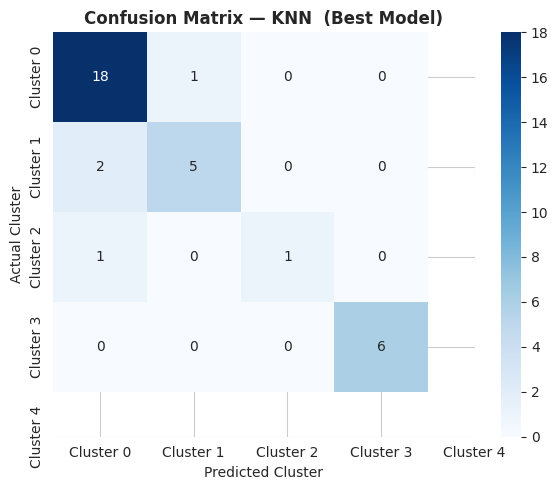


Best model: KNN
CV Accuracy: 0.9702
Test Accuracy: 0.8824


In [68]:
# Confusion matrix for the BEST model (by CV accuracy)
best_name   = comparison_df.iloc[0]['Model']
best_idx    = model_names.index(best_name)
best_pred   = all_preds[best_idx]

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in range(best_k)],
            yticklabels=[f'Cluster {i}' for i in range(best_k)])
plt.title(f'Confusion Matrix — {best_name}  (Best Model)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Cluster')
plt.tight_layout()
plt.show()

print(f'\nBest model: {best_name}')
print(f'CV Accuracy: {comparison_df.iloc[0]["CV Accuracy (5-fold)"]:.4f}')
print(f'Test Accuracy: {comparison_df.iloc[0]["Test Accuracy"]:.4f}')